<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-5/5-4-K%20Nearest%20Neighbors-Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K Nearest Neighbors

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

## Get the Data

In [ ]:
#https://www.kaggle.com/c/titanic/data

url = 'https://drive.google.com/uc?id=1zyYJMa75UXLjmODPRnl4_UrLJ0JKmEOC'
titanic_data = pd.read_csv(url)

In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Preprocessing

In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic_data = titanic_data.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis = 1)

In [ ]:
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# fill missing age with mean
age_mean = titanic_data['Age'].mean()
titanic_data['Age'] = titanic_data['Age'].fillna(age_mean)

In [ ]:
set(titanic_data['Embarked'])

{'C', 'Q', 'S', nan}

In [ ]:
titanic_data['Embarked'].describe()

,Embarked
count,889
unique,3
top,S
freq,644


In [ ]:
titanic_data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
# fill missing 'Embarked'
titanic_data['Embarked'] = titanic_data['Embarked'].fillna('S')

In [ ]:
# encode 'Sex' with digits
titanic_data['Sex'] = LabelEncoder().fit_transform(titanic_data['Sex'])

In [ ]:
# encode 'Embarked' with digits
titanic_data['Embarked'] = LabelEncoder().fit_transform(titanic_data['Embarked'])

In [ ]:
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


## Split Data to Test and Train Sets

In [ ]:
X = titanic_data.drop(['Survived'], axis = 1)
y = titanic_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

## Standardize the Variables

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [ ]:
scaled_X_train

array([[-1.566113  , -1.33871463, -0.50043013, ..., -0.46842329,
         1.67993835, -1.94344676],
       [ 0.83965282,  0.74698519,  1.03705744, ..., -0.46842329,
        -0.52289358,  0.58623166],
       [ 0.83965282, -1.33871463,  0.01456037, ..., -0.46842329,
        -0.49342213, -0.67860755],
       ...,
       [ 0.83965282,  0.74698519, -2.2362536 , ...,  0.74879344,
        -0.48027628, -1.94344676],
       [-1.566113  ,  0.74698519,  0.01456037, ..., -0.46842329,
        -0.08426968, -1.94344676],
       [-1.566113  , -1.33871463,  0.8064343 , ...,  0.74879344,
         2.11761781, -1.94344676]])

## KNN model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier()

In [ ]:
pred = knn.predict(scaled_X_test)

In [ ]:
### compare real and predicted

In [ ]:
y_test

,Survived
214,0
805,0
532,0
396,0
679,1
...,...
543,1
731,0
631,0
175,0


In [ ]:
pred

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0])

In [ ]:
list(zip(pred, y_test))
pred2 = np.array(pred, dtype=np.int64)
y_test2 = np.array(y_test, dtype=np.int64)
diff = np.abs(pred2 - y_test2)
diff.size // 170
count_errors = np.sum(diff == 1)
# count_errors
count_errors / diff.size

np.float64(0.2681564245810056)

## Evaluation

In [ ]:
cm = confusion_matrix(y_test,pred)
cm

# [[TN  FP]
#  [FN  TP]]
# 118 passengers correctly predicted as not survived (0).
# 9 passengers predicted as survived (1) but actually didn’t survive.
# 20 passengers predicted as not survived (0) but actually survived.
# 32 passengers correctly predicted as survived (1).

array([[92, 18],
       [30, 39]])

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       110
           1       0.68      0.57      0.62        69

    accuracy                           0.73       179
   macro avg       0.72      0.70      0.71       179
weighted avg       0.73      0.73      0.73       179



In [ ]:
accuracy_score(y_test,pred)

0.7318435754189944

## Choosing a K Value

In [ ]:
error_rate = []

for i in range(1,30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_X_train,y_train)
    pred_i = knn.predict(scaled_X_test)
    error_rate.append(np.mean(pred_i != y_test))

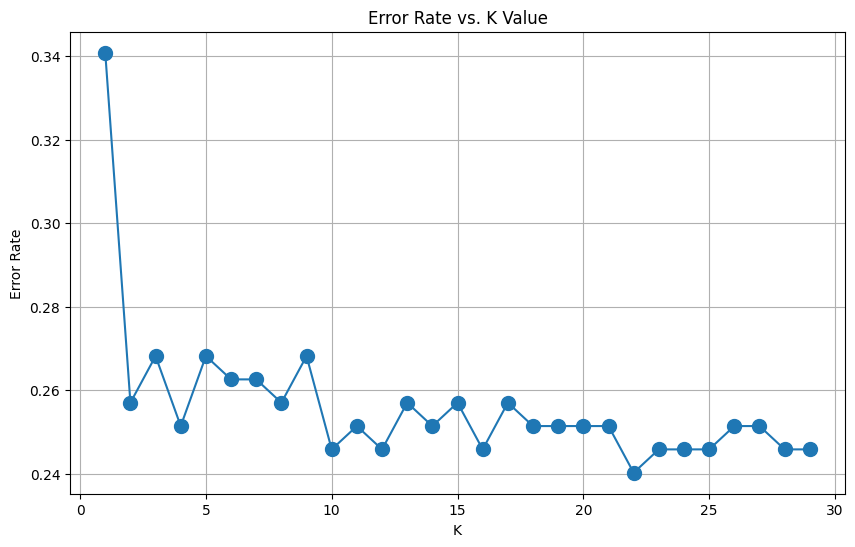

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,30), error_rate, marker='o', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(scaled_X_train,y_train)
pred = knn.predict(scaled_X_test)

print(confusion_matrix(y_test,pred))
print()
print(classification_report(y_test,pred))

[[100  10]
 [ 34  35]]

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       110
           1       0.78      0.51      0.61        69

    accuracy                           0.75       179
   macro avg       0.76      0.71      0.72       179
weighted avg       0.76      0.75      0.74       179



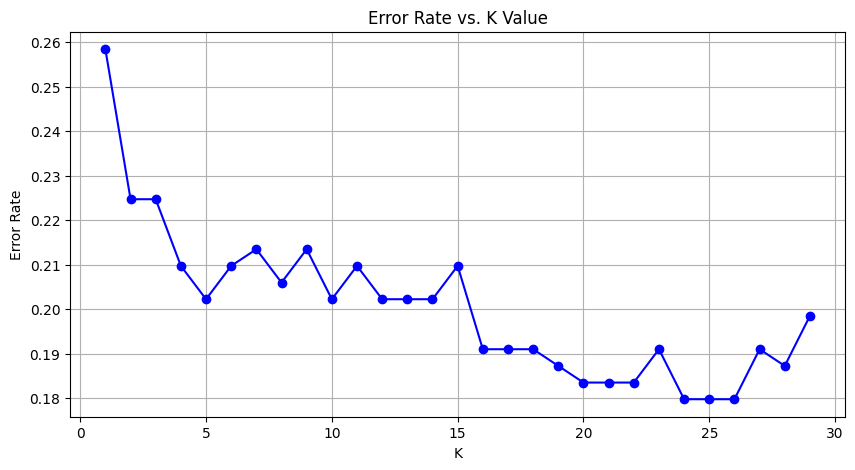


Матриця помилок (Confusion Matrix):
[[148  19]
 [ 35  65]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       167
           1       0.77      0.65      0.71       100

    accuracy                           0.80       267
   macro avg       0.79      0.77      0.78       267
weighted avg       0.80      0.80      0.79       267



In [ ]:
#version 2.0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Завантаження даних
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_data = pd.read_csv(url)

# 2. Швидка очистка (заповнюємо пусті місця та видаляємо непотрібний текст)
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())
titanic_data = titanic_data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).dropna()

# Кодуємо стать (текст) у цифри
le = LabelEncoder()
titanic_data['Sex'] = le.fit_transform(titanic_data['Sex'])
titanic_data['Embarked'] = le.fit_transform(titanic_data['Embarked'])

# Ознаки та таргет
X = titanic_data.drop(columns=['Survived'])
y = titanic_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Масштабування (обов'язково для KNN)
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

# 4. Навчання та пошук найкращого K
error_rate = []
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_X_train, y_train)
    pred_i = knn.predict(scaled_X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Графік помилок
plt.figure(figsize=(10, 5))
plt.plot(range(1, 30), error_rate, marker='o', color='blue')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()
plt.show()

# Фінальна модель (наприклад, для K=10)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(scaled_X_train, y_train)
pred = knn.predict(scaled_X_test)

print("\nМатриця помилок (Confusion Matrix):")
print(confusion_matrix(y_test, pred))
print("\nЗвіт класифікації:")
print(classification_report(y_test, pred))